In [1]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

In [3]:
df = pd.read_csv("data/stud.csv")
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
X = df.drop("math_score", axis="columns")
y = df.math_score

In [5]:
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [6]:
y.head()

0    72
1    69
2    90
3    47
4    76
Name: math_score, dtype: int64

In [9]:
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
ohe_transformer = OneHotEncoder()

ct = ColumnTransformer(
    [
        ("OneHotEncoder", ohe_transformer, cat_features),
         ("StandardScaler", numeric_transformer, num_features),        
    ]
)

C:\Users\mohni\AppData\Local\Temp\ipykernel_17392\3845743197.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X.select_dtypes(include="object").columns


In [10]:
X = ct.fit_transform(X)

In [11]:
X.shape

(1000, 19)

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=44)

In [22]:
X_train.shape

(750, 19)

In [23]:
X_test.shape

(250, 19)

In [24]:
def evaluate_model(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2_squared = r2_score(actual, predicted)
    return mae, mse, rmse, r2_squared

In [25]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}

In [35]:
model_list = []
r2_list = []

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_predicted = model.predict(X_test)
    evaluation = evaluate_model(y_test, y_predicted)
    r2_squared = r2_score(y_test, y_predicted)
    model_list.append(model_name)
    r2_list.append(r2_squared)
model_list, r2_list

(['Linear Regression',
  'Lasso',
  'Ridge',
  'K-Neighbors Regressor',
  'Decision Tree',
  'Random Forest Regressor',
  'XGBRegressor',
  'CatBoosting Regressor',
  'AdaBoost Regressor'],
 [0.8757895976827696,
  0.8280975597509737,
  0.876022840337689,
  0.7991937210987735,
  0.7076425165633262,
  0.8528992944041153,
  0.8138487339019775,
  0.86088642150277,
  0.8328786849675378])

In [42]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=["Model Name", "Scores"])

,Model Name,Scores
0,Linear Regression,0.875790
1,Lasso,0.828098
2,Ridge,0.876023
3,K-Neighbors Regressor,0.799194
4,Decision Tree,0.707643
5,Random Forest Regressor,0.852899
6,XGBRegressor,0.813849
7,CatBoosting Regressor,0.860886
8,AdaBoost Regressor,0.832879


**INSIGHTS :-**

Linear Regression and the ridge regression has the highest accuracy among the others.

<Axes: xlabel='math_score', ylabel='Predicted Values'>

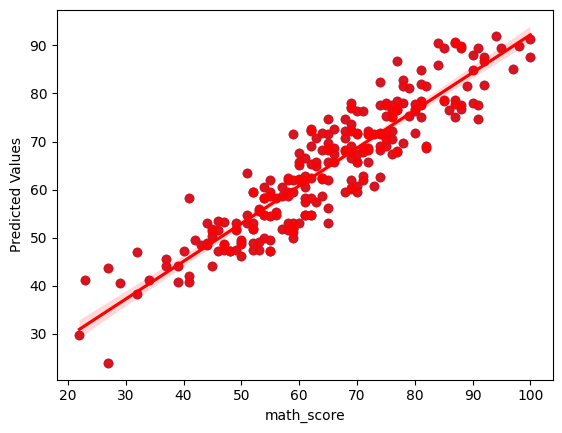

In [48]:
plt.scatter(y_test, y_predicted)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
sns.regplot(x=y_test, y=y_predicted, color="Red")